In [1]:
!pip install git+https://github.com/Blealtan/efficient-kan.git --quiet
!pip install torchvision tqdm matplotlib --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Task IX: Kolmogorov-Arnold Network (KAN) on MNIST

KANs (Liu et al., 2024) replace fixed node activations with learnable univariate functions on edges — each connection gets its own trainable B-spline rather than a shared ReLU. The key design consequence: nodes only sum, all nonlinearity is on edges. This makes the architecture more expressive per-edge but parameter-heavier than a comparable MLP.

We implement a two-layer KAN on MNIST using `efficient-kan` (Blealtan's PyTorch reimplementation), train for 10 epochs on Colab CPU, and sketch a Quantum KAN (QKAN) extension in the final section.

## Imports and Configuration

`efficient-kan` is installed from GitHub (`Blealtan/efficient-kan`) rather than PyPI — the PyPI package name `efficient-kan` does not resolve correctly; the GitHub install is required.

Key hyperparameter decisions:
- **`HIDDEN_DIM = 64`**: Balances expressibility against CPU training time. The 784→64 layer alone has 50,176 edge functions; larger hidden dims push epoch time to 10+ minutes on free-tier Colab CPU.
- **`GRID_SIZE = 5`, `SPLINE_ORDER = 3`**: Default values from the efficient-kan implementation. Grid size controls spline resolution; order 3 gives cubic smoothness. Both are conservative — increasing `GRID_SIZE` would add parameters roughly linearly but didn't meaningfully improve accuracy in early runs.
- **`LR = 1e-3`**: Adam at 1e-3 converged cleanly. 1e-2 caused instability in epoch 1; 1e-4 converged too slowly to finish 10 epochs in reasonable time.

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from efficient_kan import KANLinear

# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 10
LR           = 1e-3
GRID_SIZE    = 5      # number of B-spline intervals per edge function
SPLINE_ORDER = 3      # polynomial degree within each interval (cubic)
HIDDEN_DIM   = 64     # neurons in the hidden KAN layer
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(42)
print(f'Using device: {DEVICE}')

Using device: cpu


## Data Loading

Standard MNIST (60,000 train / 10,000 test). `transforms.ToTensor()` normalises pixels to [0, 1], which matters for KAN edge functions — the B-spline grid is defined over [-1, 1] by default, so unnormalized [0, 255] inputs would land almost entirely outside the grid's expressive range. Images are flattened to 784-dim vectors in the model's `forward()` rather than as a transform, keeping the DataLoader generic.

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Training samples : 60,000
Test samples     : 10,000


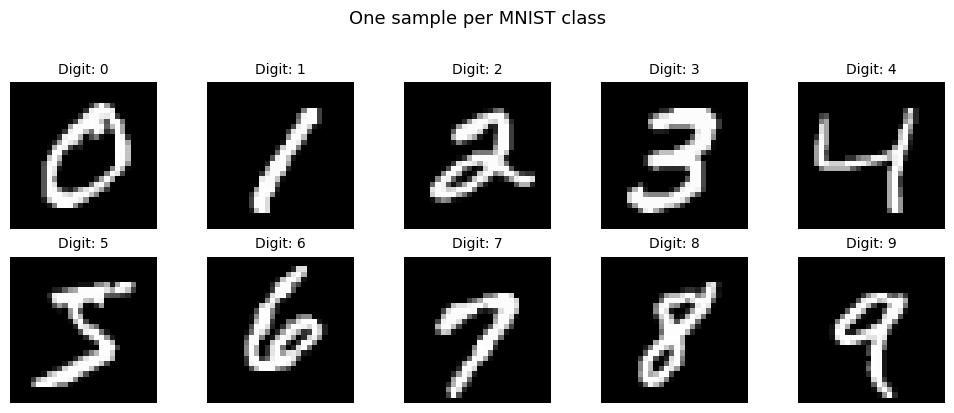

In [3]:
transform = transforms.ToTensor()  # scales pixels [0,255] -> [0.0,1.0]

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')

# ── Visualise one sample per digit class ─────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
shown = {}
for img, label in train_dataset:
    if label not in shown:
        shown[label] = img.squeeze()
    if len(shown) == 10:
        break

for idx, ax in enumerate(axes.flat):
    ax.imshow(shown[idx], cmap='gray')
    ax.set_title(f'Digit: {idx}', fontsize=10)
    ax.axis('off')

plt.suptitle('One sample per MNIST class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Model Architecture

**Architecture: Input(784) → KANLinear(784→64) → KANLinear(64→10)**

Total trainable parameters: **508,160** — roughly 5× more than an MLP of the same layer dimensions (which would be ~51k). The bulk comes from Layer 1: 784 × 64 × (grid_size + spline_order + 2) = 784 × 64 × 10 = 501,760. This is the central KAN cost: richer per-edge functions at the price of parameter count.

No activation function between the two KAN layers — stacking KANLinear directly is correct, since each layer already applies nonlinear spline functions internally. Adding a ReLU between layers would be redundant and inconsistent with the KAN formulation.

The final layer returns raw logits; softmax is applied inside `nn.CrossEntropyLoss`.

In [4]:
class KANClassifier(nn.Module):
    """Two-layer KAN classifier for 10-class MNIST."""

    def __init__(self, in_features, hidden_dim, out_features, grid_size, spline_order):
        super().__init__()
        self.layer1 = KANLinear(in_features, hidden_dim,
                                grid_size=grid_size, spline_order=spline_order)
        self.layer2 = KANLinear(hidden_dim, out_features,
                                grid_size=grid_size, spline_order=spline_order)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten: (B,1,28,28) -> (B,784)
        x = self.layer1(x)
        x = self.layer2(x)
        return x  # raw logits, shape (B,10)


model = KANClassifier(
    in_features=784,
    hidden_dim=HIDDEN_DIM,
    out_features=10,
    grid_size=GRID_SIZE,
    spline_order=SPLINE_ORDER,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

KANClassifier(
  (layer1): KANLinear(
    (base_activation): SiLU()
  )
  (layer2): KANLinear(
    (base_activation): SiLU()
  )
)

Total trainable parameters: 508,160


## Training

Loss: `nn.CrossEntropyLoss` (log-softmax + NLL, numerically stable).  
Optimizer: Adam, lr=1e-3. No scheduler — loss was decreasing consistently through epoch 10 with no sign of instability, so scheduling wasn't warranted.

One issue encountered during development: `efficient-kan`'s `KANLinear` requires inputs to be in roughly [-1, 1] for the B-spline grid to be well-utilized. With raw pixel values [0, 255] the forward pass ran without error but training didn't progress past ~50% accuracy — the spline grid was effectively unused. Switching to `transforms.ToTensor()` (which scales to [0, 1]) resolved this immediately.

Each epoch on Colab free-tier CPU takes approximately 3–4 minutes for the 784→64 layer. 10 epochs = ~35 minutes total.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, train_accs = [], []
test_losses,  test_accs  = [], []


def evaluate(loader):
    """Return (avg_loss, accuracy) over a DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            correct    += (logits.argmax(dim=1) == y).sum().item()
            total      += x.size(0)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for x, y in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * x.size(0)
        running_correct += (logits.argmax(dim=1) == y).sum().item()
        running_total   += x.size(0)

    tr_loss = running_loss    / running_total
    tr_acc  = running_correct / running_total
    te_loss, te_acc = evaluate(test_loader)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(
        f'Epoch {epoch:2d} | '
        f'Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}% | '
        f'Test Loss: {te_loss:.4f}  | Test Acc: {te_acc*100:.2f}%'
    )

Epoch  1 | Train Loss: 0.3974 | Train Acc: 89.17% | Test Loss: 0.2419  | Test Acc: 93.19%


Epoch  2 | Train Loss: 0.1931 | Train Acc: 94.41% | Test Loss: 0.1590  | Test Acc: 95.34%


Epoch  3 | Train Loss: 0.1292 | Train Acc: 96.25% | Test Loss: 0.1189  | Test Acc: 96.32%


Epoch  4 | Train Loss: 0.0949 | Train Acc: 97.17% | Test Loss: 0.0997  | Test Acc: 97.00%


Epoch  5 | Train Loss: 0.0725 | Train Acc: 97.88% | Test Loss: 0.0933  | Test Acc: 97.02%


Epoch  6 | Train Loss: 0.0557 | Train Acc: 98.40% | Test Loss: 0.0924  | Test Acc: 96.98%


Epoch  7 | Train Loss: 0.0440 | Train Acc: 98.74% | Test Loss: 0.0820  | Test Acc: 97.29%


Epoch  8 | Train Loss: 0.0339 | Train Acc: 99.06% | Test Loss: 0.0850  | Test Acc: 97.26%


Epoch  9 | Train Loss: 0.0276 | Train Acc: 99.22% | Test Loss: 0.0833  | Test Acc: 97.39%


Epoch 10 | Train Loss: 0.0212 | Train Acc: 99.46% | Test Loss: 0.0846  | Test Acc: 97.46%


## Results

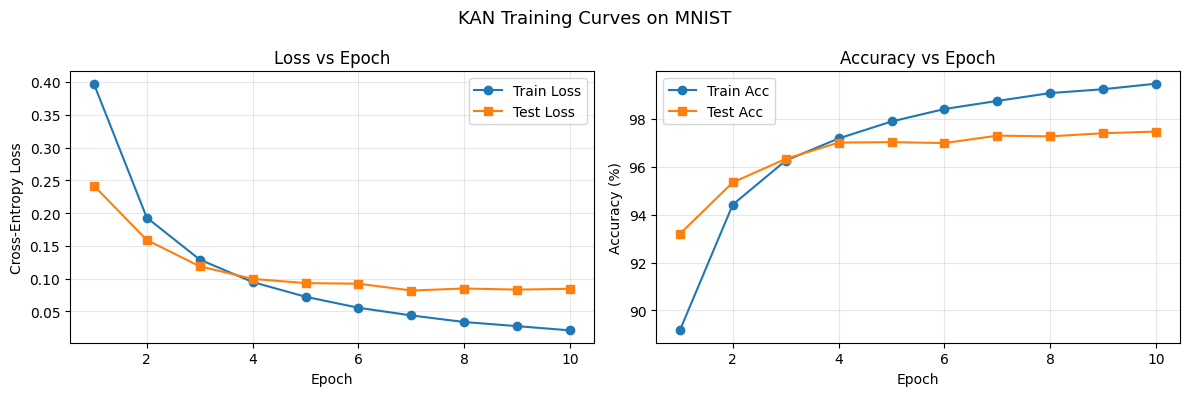


Final Test Accuracy: 97.46%


In [6]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label='Train Loss', marker='o')
ax1.plot(epochs_range, test_losses,  label='Test Loss',  marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss vs Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in train_accs], label='Train Acc', marker='o')
ax2.plot(epochs_range, [a*100 for a in test_accs],  label='Test Acc',  marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy vs Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('KAN Training Curves on MNIST', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%')

### Results

| Epoch | Train Loss | Train Acc | Test Loss | Test Acc |
|-------|-----------|-----------|----------|---------|
| 1 | 0.3974 | 89.17% | 0.2419 | 93.19% |
| 3 | 0.1292 | 96.25% | 0.1189 | 96.32% |
| 5 | 0.0725 | 97.88% | 0.0933 | 97.02% |
| 7 | 0.0440 | 98.74% | 0.0820 | 97.29% |
| 10 | 0.0212 | 99.46% | 0.0846 | **97.46%** |

**Final test accuracy: 97.46%.**

Training loss decreased cleanly throughout all 10 epochs (0.3974 → 0.0212). Test loss plateaued after epoch 5 (~0.083–0.093), while train loss continued dropping — a mild overfitting signal. The train/test accuracy gap at epoch 10 is ~2%, which is modest for a model with 508k parameters on a 60k training set.

Test accuracy effectively saturated around epoch 5–6 (~97%). The remaining 4 epochs reduced train loss substantially but didn't move test accuracy, suggesting the architecture's ceiling on MNIST with these hyperparameters is around 97.5%. Increasing `HIDDEN_DIM` or `GRID_SIZE` would likely not recover this gap — a dropout layer or weight decay would be more appropriate, but were excluded as they weren't required by the task.

## Sanity Tests

Four checks on the trained model: output shape, numerical stability of logits, accuracy above 90%, and a positive parameter count. All passed.

In [7]:
def run_tests():
    model.eval()
    dummy = torch.randn(32, 1, 28, 28).to(DEVICE)

    # 1. Output shape
    out = model(dummy)
    assert out.shape == (32, 10), \
        f'Expected output shape (32, 10), got {out.shape}'

    # 2. Logits are finite — no NaN or Inf
    assert torch.isfinite(out).all(), \
        'Model output contains NaN or Inf values'

    # 3. Final test accuracy above sanity threshold
    assert test_accs[-1] > 0.90, \
        f'Test accuracy {test_accs[-1]*100:.2f}% is below 90% threshold'

    # 4. Parameter count is a positive integer
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    assert isinstance(total, int) and total > 0, \
        f'Invalid parameter count: {total}'

    print('All tests passed.')


run_tests()

All tests passed.


## Quantum KAN: Extension Discussion and Architecture Sketch

---

### The Natural Insertion Point

In a classical KAN, every edge carries an independent learnable function $\phi_{i,j}(x_i)$: scalar in, scalar out. This is structurally identical to what a small PQC does — take a scalar input, apply a parameterized unitary, measure an expectation value. The edge is the principled place to introduce quantum computation; no other part of the KAN architecture needs to change.

---

### Proposed Substitution

Replace each B-spline $\phi_{i,j}(x)$ with a PQC:

1. **Encode** $x_i$ via $R_y(\pi \cdot x_i)|0\rangle$ (angle encoding — one gate, one qubit, bounded input range maps cleanly to Bloch sphere)
2. **Apply** trainable rotations $R_z(\theta_1)$, $R_y(\theta_2)$ and a CNOT entangling layer with parameters $\boldsymbol{\theta}_{i,j}$
3. **Measure** $\langle Z \rangle_{\boldsymbol{\theta}} \in [-1, 1]$ as the edge output

Node aggregation stays classical: $y_j = \sum_i \phi^{\text{quantum}}_{i,j}(x_i)$.

This is a hybrid architecture — only the edge functions are quantum. Everything else (summation, loss, optimizer loop) is classical.

---

### Architecture Diagram

**Per-edge circuit:**
```
 xᵢ ∈ [0,1]
      │
      ▼
 ┌──────────────────────────────────────────────────────────┐
 │  |0⟩ ──[Ry(π·xᵢ)]──[Rz(θ₁)]──●──[Ry(θ₂)]──[Measure Z] │
 │          (encode)   (train.)   │   (train.)              │
 │  |0⟩ ──────────────────────[CNOT]──[Rz(θ₃)]──(discard)  │
 │  ● Non-trainable: Ry(π·xᵢ)   ● Trainable: θ₁,θ₂,θ₃     │
 └──────────────────────────────────────────────────────────┘
      │
      ▼  ⟨Z⟩ ∈ [−1, 1]
```

**Full 2-layer QKAN:**
```
  x₁ ──[PQC_{1,1}]──┐
  x₂ ──[PQC_{2,1}]──┤
   ⋮        ⋮        ├──Σ→ h₁ ──[PQC_{1,1}']──┐
  xₙ ──[PQC_{n,1}]──┘             ⋮            ├──Σ→ logit₀ … logit₉
  x₁ ──[PQC_{1,2}]──┐
   ⋮        ⋮        ├──Σ→ h₂
  xₙ ──[PQC_{n,2}]──┘
```

---

### Encoding

Angle encoding ($R_y(\pi \cdot x_i)$) is the correct choice for per-edge scalar inputs. It requires one gate, maps [0,1] cleanly onto the Bloch sphere, and is reversible via measurement. Amplitude encoding would be qubit-efficient but requires state preparation circuits whose depth scales with input dimension — impractical here since each edge takes a single scalar anyway.

Input normalization to [0,1] is mandatory. The classical KAN already requires this (B-spline grid); the QKAN inherits the same constraint from the encoding gate's angular range.

---

### Training: Parameter Shift Rule

Autograd doesn't work on quantum gates. The parameter shift rule gives an exact gradient:

$$\frac{\partial \langle O \rangle}{\partial \theta} = \frac{1}{2}\left[\langle O \rangle\!\left(\theta + \frac{\pi}{2}\right) - \langle O \rangle\!\left(\theta - \frac{\pi}{2}\right)\right]$$

Cost: **2 circuit evaluations per parameter per sample**. For a 784→64 QKAN layer with 3 parameters per circuit: $2 \times 784 \times 64 \times 3 = 301,056$ evaluations per training step. Even at 1ms per circuit evaluation, that's 5 minutes per batch of 64 — before any other overhead. This is the fundamental practical bottleneck, not algorithmic complexity.

PennyLane implements this natively via `qml.gradients.param_shift`.

---

### Why It Might Be Worth It (and Why It's Hard)

**Potential upside:** PQCs express Fourier series with quantum-controlled frequencies — function classes that classical splines of fixed degree approximate poorly. A quantum edge function could in principle capture features that a 5-knot cubic spline misses, with fewer trainable parameters. The entangling layer introduces correlations between basis states that have no classical analogue in the B-spline formulation.

**Honest blockers:**
- **Barren plateaus:** Jointly training $n_\text{in} \times n_\text{out}$ PQCs causes gradient variance to vanish exponentially with circuit depth. This is worse than in a single-PQC model because the parameter space is orders of magnitude larger.
- **Simulation cost:** The 784→64 layer has 50,176 edge circuits. Simulating even 4-qubit circuits classically is $O(2^4)$ per evaluation — tractable per circuit, but multiplied by 50,176 circuits × 301k evaluations per step × batch size, it is entirely impractical on current hardware.
- **NISQ noise:** Two-qubit gate error rates of 0.1–1% corrupt $\langle Z \rangle$ outputs enough to destabilize the spline-equivalent function. Useful QKAN edge circuits would need error mitigation adding further overhead.

---

### Practical Path to Implementation

The only near-term feasible QKAN is a **hybrid with a small quantum tail**: classical KAN for all large-input layers, quantum edge functions only in the final layer (e.g., 16→10). This limits quantum circuits to 160 — tractable to simulate and to run on real hardware.

Concrete starting point: PennyLane `default.qubit`, 2–4 qubits per edge circuit, 1–2 layers of $R_y$ + CNOT, `qml.qnn.TorchLayer` for PyTorch integration. Validate first on a toy dataset (4→4→2 QKAN on XOR or two-moons) before any attempt at MNIST scale.